In [ ]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса

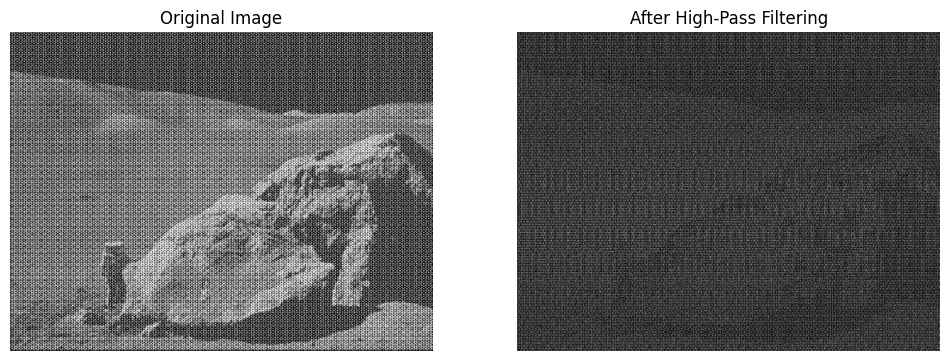

In [6]:
img = cv2.imread('periodic_noise.jpg', cv2.IMREAD_GRAYSCALE)

def create_gaussian_high_pass(size, sigma):
    center = size // 2
    x = np.arange(0, size) - center
    y = np.arange(0, size) - center
    X, Y = np.meshgrid(x, y)
    gaussian_low_pass = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    gaussian_high_pass = 1 - gaussian_low_pass
    return gaussian_high_pass

def apply_high_pass_filter(image, kernel):
    dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    
    kernel_resized = cv2.resize(kernel, (image.shape[1], image.shape[0]))
    
    dft_shift[:, :, 0] *= kernel_resized
    dft_shift[:, :, 1] *= kernel_resized
    
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    
    return img_back

kernel_size = 31
sigma = 10
high_pass_kernel = create_gaussian_high_pass(kernel_size, sigma)
filtered_img = apply_high_pass_filter(img, high_pass_kernel)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('After High-Pass Filtering')
plt.imshow(filtered_img, cmap='gray')
plt.axis('off')
plt.show()


# Реализуйте удаление периодического шума

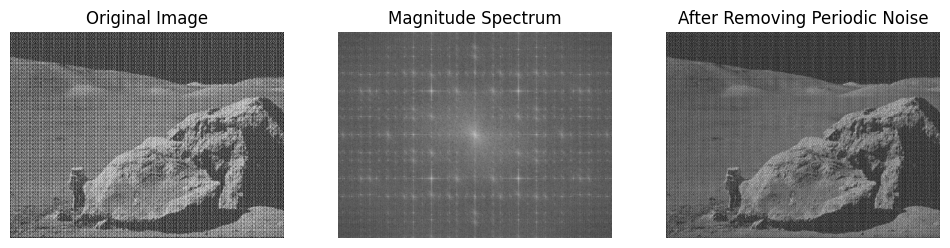

In [20]:
from skimage.feature import peak_local_max

dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)
local_max = peak_local_max(magnitude_spectrum, min_distance=10, threshold_rel=0.5)

mask = np.ones((img.shape[0], img.shape[1], 2), dtype=np.float32)
center_x, center_y = img.shape[1] // 2, img.shape[0] // 2

for (y, x) in local_max:
    distance = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    if distance > 20:
        mask[y, x, :] = 0

dft_shift_filtered = dft_shift * mask
f_ishift = np.fft.ifftshift(dft_shift_filtered)
img_filtered = cv2.idft(f_ishift)
img_filtered = cv2.magnitude(img_filtered[:, :, 0], img_filtered[:, :, 1])

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Magnitude Spectrum')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('After Removing Periodic Noise')
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')
plt.show()